## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import os

print("tensorflow version:", tf.__version__)

tensorflow version: 2.21.0


## Load the Dataset

In [3]:
text = open('shakespeare.txt', 'rb').read().decode(encoding='utf-8')

print("total characters in corpus:", len(text))
print()
print("first 300 characters:")
print(text[:300])

total characters in corpus: 1115394

first 300 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## EDA 

In [4]:
# find all unique characters - this is our vocabulary
vocab = sorted(set(text))

print("total unique characters (vocab size):", len(vocab))
print()
print("vocabulary:")
print(''.join(vocab))

total unique characters (vocab size): 65

vocabulary:

 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


## Preprocessing

models cannot read text directly - we need to convert characters to numbers

- char2idx = dictionary: character → number
- idx2char = dictionary: number → character

In [5]:
# create character to index mapping
char2idx = {char: idx for idx, char in enumerate(vocab)}
idx2char = np.array(vocab)

print("example mappings:")
print("'a' ->", char2idx['a'])
print("'A' ->", char2idx['A'])
print("' ' ->", char2idx[' '])
print()

# convert full text to numbers
text_as_int = np.array([char2idx[c] for c in text])

print("first 10 chars:", text[:10])
print("as numbers:    ", text_as_int[:10])

example mappings:
'a' -> 39
'A' -> 13
' ' -> 1

first 10 chars: First Citi
as numbers:     [18 47 56 57 58  1 15 47 58 47]


## Create Input and Target Sequences

the model learns: given sequence of characters, predict the next character

example with seq_length = 5:
- input  = 'H E L L O'
- target = 'E L L O !'

each input character maps to the character that comes after it

In [6]:
seq_length = 100    # how many characters the model reads at one time
vocab_size = len(vocab)

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

# split each sequence into input and target
def split_input_target(chunk):
    input_text  = chunk[:-1]   
    target_text = chunk[1:]    
    return input_text, target_text

dataset = sequences.map(split_input_target)

# example
for input_example, target_example in dataset.take(1):
    print("input sequence: ", repr(''.join(idx2char[input_example.numpy()[:20]])))
    print("target sequence:", repr(''.join(idx2char[target_example.numpy()[:20]])))

input sequence:  'First Citizen:\nBefor'
target sequence: 'irst Citizen:\nBefore'


In [7]:
# create batches and shuffle
BATCH_SIZE = 64
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

print("dataset shape:")
for x, y in dataset.take(1):
    print("input batch shape: ", x.shape)  
    print("target batch shape:", y.shape)   

dataset shape:
input batch shape:  (64, 100)
target batch shape: (64, 100)


## Build the Models

all 3 models have same structure - only the recurrent layer changes:
- Embedding layer = converts number to dense vector (better than one-hot)
- RNN / LSTM / GRU = the recurrent layer that learns sequence patterns
- Dense layer = outputs probability for each character in vocab

In [ ]:
embedding_dim = 256    
rnn_units     = 512    

def build_model(rnn_type='lstm', batch_size=BATCH_SIZE):
    if rnn_type == 'rnn':
        recurrent_layer = layers.SimpleRNN(
            rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer='glorot_uniform'
        )
    elif rnn_type == 'lstm':
        recurrent_layer = layers.LSTM(
            rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer='glorot_uniform'
        )
    elif rnn_type == 'gru':
        recurrent_layer = layers.GRU(
            rnn_units,
            return_sequences=True,
            stateful=True,
            recurrent_initializer='glorot_uniform'
        )
    else:
        raise ValueError(f"Unknown rnn_type: {rnn_type}")


    model = keras.Sequential([
    layers.Input(batch_shape=(batch_size, None)),
    layers.Embedding(vocab_size, embedding_dim),
    recurrent_layer,
    layers.Dense(vocab_size)
])

    return model

# build all 3 models
rnn_model  = build_model(rnn_type='rnn')
lstm_model = build_model(rnn_type='lstm')
gru_model  = build_model(rnn_type='gru')

print("RNN model:")
rnn_model.summary()
print()
print("LSTM model:")
lstm_model.summary()
print()
print("GRU model:")
gru_model.summary()


RNN model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (64, None, 256)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (64, None, 512)        │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 65)         │        33,345 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 443,713 (1.69 MB)

 Trainable params: 443,713 (1.69 MB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (64, None, 256)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (64, None, 512)        │     1,182,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (64, None, 65)         │        33,345 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,232,705 (4.70 MB)

 Trainable params: 1,232,705 (4.70 MB)

 Non-trainable params: 0 (0.00 B)

## Define Loss Function and Compile

we use sparse categorical crossentropy  
sparse = labels are integers not one-hot  
from_logits = model outputs raw scores not probabilities

In [11]:
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(
        labels, logits, from_logits=True
    )

# compile all 3 models
rnn_model.compile(optimizer='adam', loss=loss)
lstm_model.compile(optimizer='adam', loss=loss)
gru_model.compile(optimizer='adam', loss=loss)

print("all 3 models compiled")

all 3 models compiled


## Train the Models

In [13]:
EPOCHS = 10

# --- train RNN ---
print("training Vanilla RNN...")
checkpoint_dir_rnn = './checkpoints_rnn'
os.makedirs(checkpoint_dir_rnn, exist_ok=True)
checkpoint_callback_rnn = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir_rnn, 'ckpt_{epoch}.weights.h5'),
    save_weights_only=True
)
rnn_history = rnn_model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback_rnn]
)

# --- train LSTM ---
print("training LSTM...")
checkpoint_dir_lstm = './checkpoints_lstm'
os.makedirs(checkpoint_dir_lstm, exist_ok=True)
checkpoint_callback_lstm = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir_lstm, 'ckpt_{epoch}.weights.h5'),
    save_weights_only=True
)
lstm_history = lstm_model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback_lstm]
)

# --- train GRU ---
print("training GRU...")
checkpoint_dir_gru = './checkpoints_gru'
os.makedirs(checkpoint_dir_gru, exist_ok=True)
checkpoint_callback_gru = keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir_gru, 'ckpt_{epoch}.weights.h5'),
    save_weights_only=True
)
gru_history = gru_model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback_gru]
)

training Vanilla RNN...
Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 45s 247ms/step - loss: 2.4556
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - loss: 1.9643
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - loss: 1.7953
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 38s 212ms/step - loss: 1.6900
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - loss: 1.6201
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 40s 224ms/step - loss: 1.5720
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 219ms/step - loss: 1.5333
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 40s 226ms/step - loss: 1.5045
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 221ms/step - loss: 1.4801
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 219ms/step - loss: 1.4597
training LSTM...
Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 467ms/step - loss: 2.4664
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 462ms/step - loss: 1.9092
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 81s 463ms/step - loss: 1.7184
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 475m

## Plot Training Loss

lower loss = model is learning better  
compare how fast each model learns

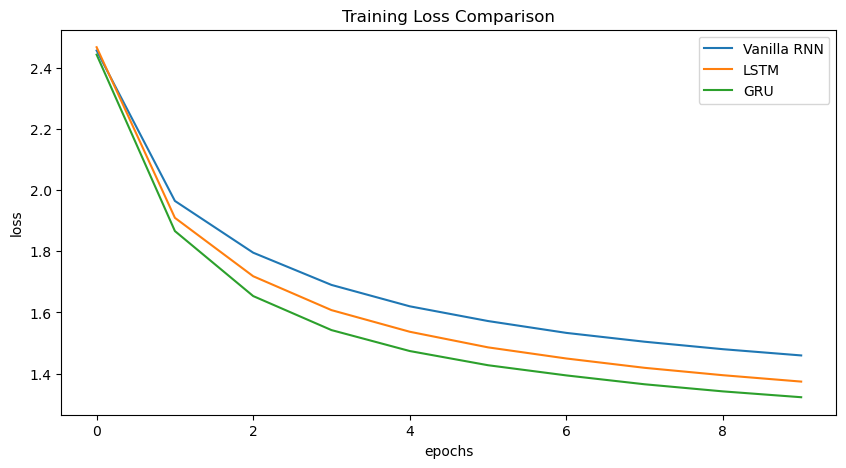

Final RNN loss:  1.4597
Final LSTM loss: 1.3743
Final GRU loss:  1.3232


In [14]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['loss'],  label='Vanilla RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'],  label='GRU')
plt.title("Training Loss Comparison")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

print(f"Final RNN loss:  {rnn_history.history['loss'][-1]:.4f}")
print(f"Final LSTM loss: {lstm_history.history['loss'][-1]:.4f}")
print(f"Final GRU loss:  {gru_history.history['loss'][-1]:.4f}")

## Text Generation Function

to generate text:
1. give the model a starting string (seed)
2. model predicts next character
3. add that character to the sequence
4. repeat until we have enough characters

temperature controls randomness:
- low temperature (0.2) = conservative, repetitive but correct grammar
- high temperature (1.0) = creative, more random, sometimes nonsense

In [15]:
def generate_text(model, start_string, num_generate=500, temperature=1.0):
    """
    model         = trained model (rnn, lstm or gru)
    start_string  = seed text to start generation
    num_generate  = how many characters to generate
    temperature   = randomness (0.2 = safe, 1.0 = creative)
    """
    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)   

    text_generated = []

    
    model.reset_states()

    for i in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0)   

        # apply temperature
        predictions = predictions / temperature

        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)

        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)

print("text generation function ready")

text generation function ready


## Load Best Weights and Build Inference Models

during training we used batch_size=64  
for text generation we need batch_size=1 (one sequence at a time)  
so we rebuild the models with batch_size=1 and load the saved weights

In [17]:
import glob

def latest_weights_checkpoint(checkpoint_dir):
    """Find the most recent .weights.h5 checkpoint file by epoch number."""
    files = glob.glob(os.path.join(checkpoint_dir, 'ckpt_*.weights.h5'))
    if not files:
        return None
    # sort by epoch number extracted from filename
    def epoch_num(f):
        name = os.path.basename(f)
        return int(name.replace('ckpt_', '').replace('.weights.h5', ''))
    return max(files, key=epoch_num)

rnn_gen  = build_model(rnn_type='rnn',  batch_size=1)
lstm_gen = build_model(rnn_type='lstm', batch_size=1)
gru_gen  = build_model(rnn_type='gru',  batch_size=1)

# load the saved weights
rnn_gen.load_weights(latest_weights_checkpoint(checkpoint_dir_rnn))
lstm_gen.load_weights(latest_weights_checkpoint(checkpoint_dir_lstm))
gru_gen.load_weights(latest_weights_checkpoint(checkpoint_dir_gru))
print("inference models ready")

inference models ready


## Generate Text with All 3 Models

In [19]:
def generate_text(model, start_string, temperature=1.0, num_generate=1000):
    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []

    # reset states on stateful recurrent layers only
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for i in range(num_generate):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, 0)
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)

see how temperature affects the quality of generated text

In [20]:
seed = "HAMLET:"
temperatures = [0.2, 0.5, 1.0]

for temp in temperatures:
    print(f"\ntemperature = {temp}")
    print("-" * 40)
    print(generate_text(lstm_gen, seed, num_generate=200, temperature=temp))
    print()


temperature = 0.2
----------------------------------------
HAMLET:
BADYNNVYVRXXX3KKKKVQWXQ$$QKQXXJKXQKXQXQXXXXXXXDDD$JKQXKKQKXKDVNXQQXXDQXDDDJ$D$XXX$DQXDCNQ&XKKKKV$VXKXjDJXXKXXXDDDDC&KKX$JV$X$XV$YXXXQKXKV$XQXXXQXJKXDDKKKVXXXDJXDDJXJXQQQXX$DDKKKV$D$VQQDQKKKVXQKXXXXQK


temperature = 0.5
----------------------------------------
HAMLET:NNVG&EVDCXGJ$xYXxDIKJSSQKK&VKVXRQXSNADVx$Qq$WlmY&QYQQDCcDJGX;$XX$JQVS$GTYMK&QKjYYZXJJXvNVOX&VXXQKUXQCJXWMQJH3KkXJHxXQ$RKHL&$YX$NNXEZJQy&CXP3KVKVxJKXLTYVRXBF&QJKXVYWKV$Lz&zQQXXDQDQM$zwYCXPK3J3CKXK$KXYZ


temperature = 1.0
----------------------------------------
HAMLET:$-
CLAQYY$$QJPVKGlYqQ&MiXthy'QUMBDIKIJKC'VD.FLkNGZ&wQQQ$NCYxjMrjQ'DGSN&$Sg'zd$BMvx3
QGjLzvYYVX;YXjRDVC3JCNJOJZDEXLSEQxVZKNuczx$ANXT$DcBQXJNjXDDQVQCrPSN$j$GjjODVtHAAdUGGHud$&V-?Nx$CQKX$jYQYXXKvQvJ&DLVM



## Compare All 3 Models

compare loss, training time, and output quality

Model Comparison
Vanilla RNN - final loss: 1.4597
LSTM        - final loss: 1.3743
GRU         - final loss: 1.3232


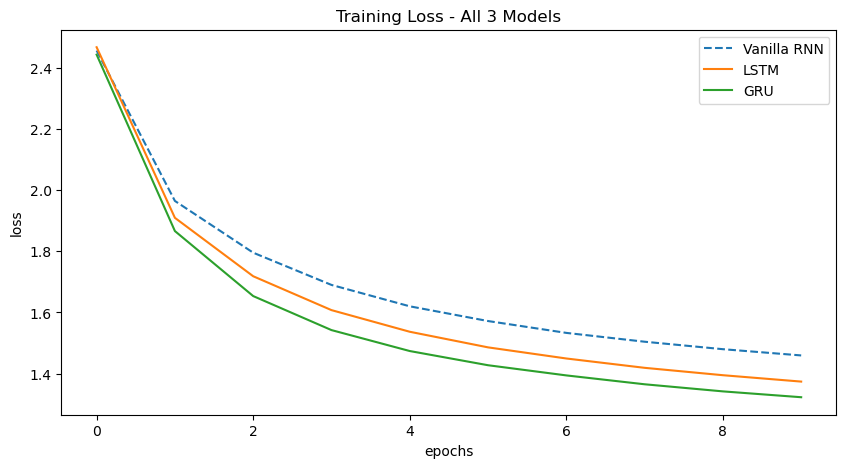

In [21]:
print("=" * 50)
print("Model Comparison")
print("=" * 50)
print(f"Vanilla RNN - final loss: {rnn_history.history['loss'][-1]:.4f}")
print(f"LSTM        - final loss: {lstm_history.history['loss'][-1]:.4f}")
print(f"GRU         - final loss: {gru_history.history['loss'][-1]:.4f}")
print("=" * 50)

# plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['loss'],  label='Vanilla RNN', linestyle='dashed')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'],  label='GRU')
plt.title("Training Loss - All 3 Models")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

## Save the Models

In [22]:
rnn_gen.save('rnn_text_gen.h5')
lstm_gen.save('lstm_text_gen.h5')
gru_gen.save('gru_text_gen.h5')

print("all 3 models saved")

all 3 models saved


## Theory Notes

**what is text generation**
- model learns patterns in text
- given N characters, predict the next one
- repeat to generate a full sequence

**Vanilla RNN**
- basic recurrent network
- has hidden state that passes between steps
- suffers from vanishing gradient = forgets old context
- good for short sequences, struggles with long text
- fastest to train

**LSTM (Long Short-Term Memory)**
- has 3 gates: input gate, forget gate, output gate
- forget gate = decides what old info to throw away
- input gate = decides what new info to store
- output gate = decides what to pass to next step
- much better at remembering long term context
- slower to train than GRU

**GRU (Gated Recurrent Unit)**
- simplified version of LSTM
- has 2 gates: reset gate and update gate
- fewer parameters than LSTM
- trains faster than LSTM
- similar performance to LSTM on most tasks

**Embedding layer**
- converts character index to a dense vector
- example: 'a' = index 10 = [0.2, 0.5, 0.1, ...] (256 values)
- learns better representations than one-hot encoding

**temperature in text generation**
- controls how random the predictions are
- low = always picks most likely character = repetitive
- high = picks random characters = creative but messy
- 0.5 is usually a good balance

**vanishing gradient problem**
- during training, gradients get very small as they go back in time
- vanilla RNN forgets context from many steps ago
- LSTM and GRU solve this with gates

**stateful = True**
- hidden state is kept between batches
- the model remembers what it saw in the previous batch
- important for text generation so context is not lost

---

## Expected Results

| model | expected loss | text quality | training speed |
|---|---|---|---|
| Vanilla RNN | highest | repetitive, loses context | fastest |
| LSTM | lowest | best coherence | slowest |
| GRU | similar to LSTM | close to LSTM | medium |

general rule: LSTM and GRU both beat vanilla RNN for text generation  
GRU is preferred when speed matters, LSTM when quality matters